In [1]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
from sklearn import datasets
import numpy as np
from time import perf_counter

In [2]:
# pomoć za merenje vremena izvršavanja
start_time = perf_counter()
for _ in range(10000):
    pass

print(f'elapsed time: {perf_counter() - start_time:.4f}')

elapsed time: 0.0003


Creates 6 2d synthetic datasets of different shapes and characteristics
    
Returns a tuple of 6 datasets

In [3]:
def create_datasets(n_samples: int = 1500) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    
    noisy_circles = datasets.make_circles(
        n_samples=n_samples, factor=0.5, noise=0.05, random_state=170
    )
    noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)
    blobs = datasets.make_blobs(n_samples=n_samples, random_state=170)
    rng = np.random.RandomState(170)
    no_structure = rng.rand(n_samples, 2), None

    # Anisotropicly distributed data
    X, y = datasets.make_blobs(n_samples=n_samples, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)
    aniso = (X_aniso, y)

    # blobs with varied variances
    varied = datasets.make_blobs(
        n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=170
    )
    return tuple(X for X, _ in (noisy_circles, noisy_moons, varied, aniso, blobs, no_structure))

In [4]:
Xs = create_datasets()

In [5]:
# Xs

Dato je šest sintetičkih skupova podataka.

Na prva 2 skupa treba pronaći 2 klastera, a na preostala 4 skupa 3 klastera.

In [6]:
n_cluster_list = [2, 2, 3, 3, 3, 3]

Na svakom od skupova podataka izvršiti hijerarhijsko klasterovanje sa 3 različite metode 
spajanja najbližih klastera – single, average i complete. Ako je potrebno, pre primene 
algoritama izvršiti odgovarajuće pretprocesiranje.

In [7]:
linkage_methods = ['single', 'average', 'complete']

models = []

for i, n_clusters in enumerate(n_cluster_list):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(Xs[i])

    for method in linkage_methods:
        
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=method
        )
        
        models.append([model, method, X_scaled])

Nacrtati mrežu scatter plotova za svaki skup i svaki model. Instance obojiti na osnovu toga 
kom klasteru pripadaju. Kao naslov svakog od grafika postaviti metodu spajanja koja je 
korišćena, silueta koeficijent i vreme izvršavanja.

In [8]:
# for X in Xs:
#     plt.scatter(X[:,0], X[:,1])

Uporediti rezultate različitih metoda spajanja na različitim skupovima podataka. Da li su 
rezultati, uključujući i vreme izvršavanja, očekivani? Da li je silueta koeficijent adekvatna 
metrika za sve skupove? Ako ne, zbog čega?

In [9]:
best_model = None
for model, method, X_scaled in models:

    start_time = perf_counter()

    y_pred = model.fit_predict(X_scaled)

    elapsed = perf_counter() - start_time
    sil_score = silhouette_score(X_scaled, y_pred)
    
    print(f'Method:{method}, elapsed time: {elapsed:.4f}, silhouette_score: {sil_score:.4f}')

Method:single, elapsed time: 0.0131, silhouette_score: 0.1139
Method:average, elapsed time: 0.0455, silhouette_score: 0.3251
Method:complete, elapsed time: 0.0423, silhouette_score: 0.3488
Method:single, elapsed time: 0.0130, silhouette_score: 0.3925
Method:average, elapsed time: 0.0478, silhouette_score: 0.4410
Method:complete, elapsed time: 0.0564, silhouette_score: 0.4930
Method:single, elapsed time: 0.0145, silhouette_score: 0.1300
Method:average, elapsed time: 0.0699, silhouette_score: 0.5119
Method:complete, elapsed time: 0.0521, silhouette_score: 0.5424
Method:single, elapsed time: 0.0136, silhouette_score: 0.2161
Method:average, elapsed time: 0.0936, silhouette_score: 0.4901
Method:complete, elapsed time: 0.0529, silhouette_score: 0.3131
Method:single, elapsed time: 0.0112, silhouette_score: 0.5408
Method:average, elapsed time: 0.0400, silhouette_score: 0.6977
Method:complete, elapsed time: 0.0395, silhouette_score: 0.6977
Method:single, elapsed time: 0.0098, silhouette_score: 

Odabrati jedan model i jedan skup podataka gde rezultati deluju dobro. Nacrtati dendrogram
za taj model.

In [10]:
best_model, best_method, best_Xs_scaled = models[-4]

Z = linkage(best_Xs_scaled, method = best_method)


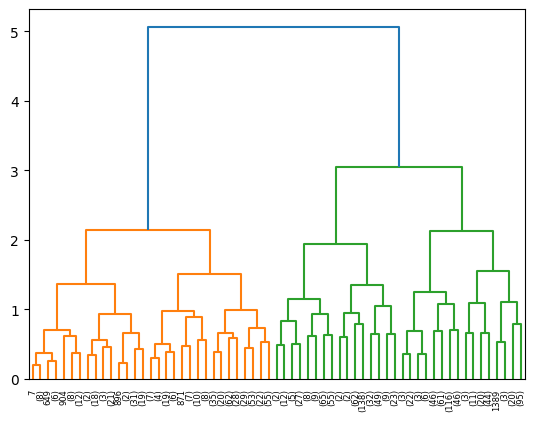

In [11]:
_ = dendrogram(Z, truncate_mode="level", p=5)